# Installs

In [1]:
!pip install pandas matplotlib seaborn plotly  fredapi

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from fredapi import Fred
import pandas as pd
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from sklearn.preprocessing import MinMaxScaler

In [3]:
fred = Fred(api_key='e956a3dbccd7d4f90be734f8d55b1d07')

series_ids = {
    'RSAFS': 'Retail Sales: All Food Services (Target)',
    'CPIAUCSL': 'Consumer Price Index',
    'UNRATE': 'Unemployment Rate',
    'FEDFUNDS': 'Federal Funds Rate',
    'PCE': 'Personal Consumption Expenditures',
    'DSPIC96': 'Real Disposable Personal Income'
}

data = pd.DataFrame()
for series_id in series_ids:
    data[series_id] = fred.get_series(series_id)

data.index = fred.get_series('RSAFS').index
data.dropna(inplace=True)

data.rename(columns=series_ids, inplace=True)
data.reset_index(inplace=True)
data.rename(columns={'index': 'ds', 'Retail Sales: All Food Services (Target)': 'y'}, inplace=True)

df = data.copy()

# EDA

Basic Info and Descriptive Stats

In [4]:
print("\n--- Data Info ---")
print(df.info())
print("\n--- Missing Values ---")
print(df.isnull().sum())
print("\n--- Descriptive Statistics ---")
print(df.describe())


--- Data Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 399 entries, 0 to 398
Data columns (total 7 columns):
 #   Column                             Non-Null Count  Dtype         
---  ------                             --------------  -----         
 0   ds                                 399 non-null    datetime64[ns]
 1   y                                  399 non-null    float64       
 2   Consumer Price Index               399 non-null    float64       
 3   Unemployment Rate                  399 non-null    float64       
 4   Federal Funds Rate                 399 non-null    float64       
 5   Personal Consumption Expenditures  399 non-null    float64       
 6   Real Disposable Personal Income    399 non-null    float64       
dtypes: datetime64[ns](1), float64(6)
memory usage: 21.9 KB
None

--- Missing Values ---
ds                                   0
y                                    0
Consumer Price Index                 0
Unemployment Rate               

TIME SERIES PLOTS FOR ALL VARIABLES

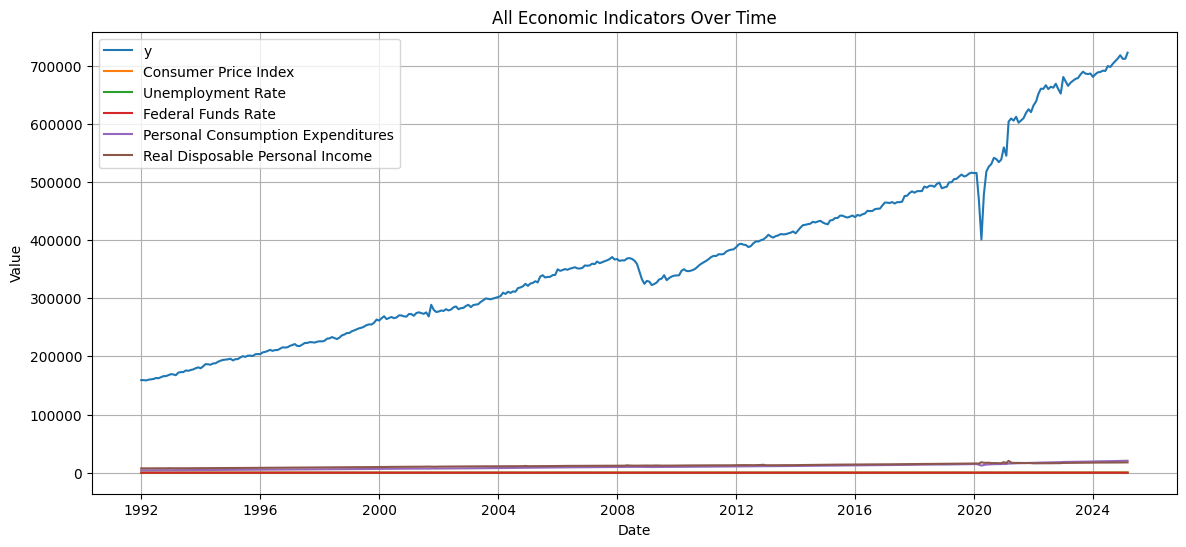

In [5]:
plt.figure(figsize=(14, 6))
for col in df.columns[1:]:
    plt.plot(df['ds'], df[col], label=col)
plt.title("All Economic Indicators Over Time")
plt.xlabel("Date")
plt.ylabel("Value")
plt.legend()
plt.grid(True)
plt.show()

UNEMPLOYMENT RATE ANALYSIS

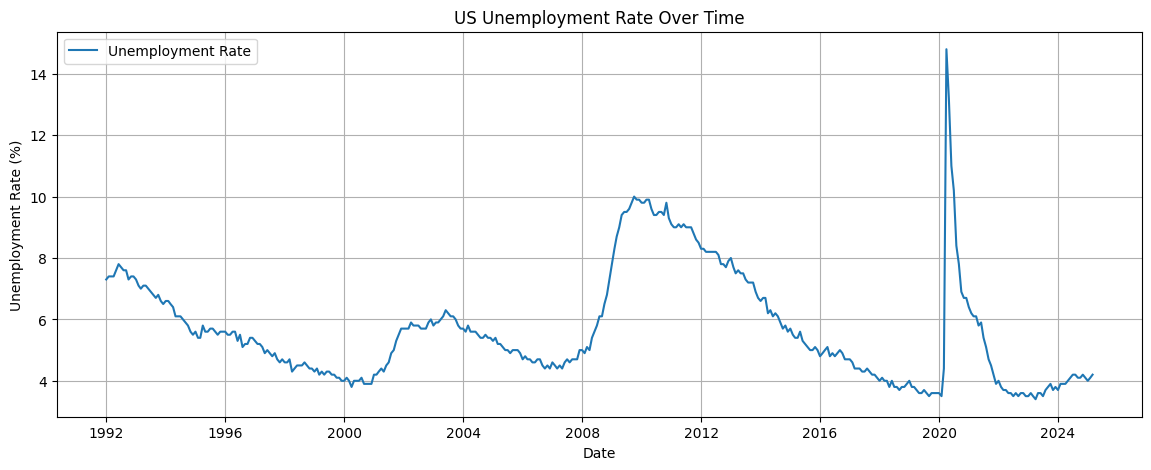

In [6]:
plt.figure(figsize=(14, 5))
plt.plot(df['ds'], df['Unemployment Rate'], label='Unemployment Rate')
plt.title("US Unemployment Rate Over Time")
plt.xlabel("Date")
plt.ylabel("Unemployment Rate (%)")
plt.grid(True)
plt.legend()
plt.show()

Plot: Unemployment Rate Over Time (interactive)


In [7]:
fig = px.line(df, x='ds', y='Unemployment Rate', title='US Unemployment Rate Over Time (Interactive)')
fig.show()

Distribution of Unemployment Rat

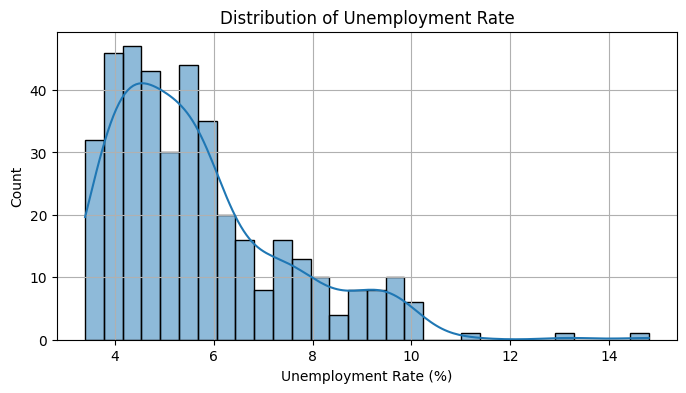

In [8]:
plt.figure(figsize=(8, 4))
sns.histplot(df['Unemployment Rate'], kde=True, bins=30)
plt.title("Distribution of Unemployment Rate")
plt.xlabel("Unemployment Rate (%)")
plt.grid(True)
plt.show()

Boxplot (to detect outliers)

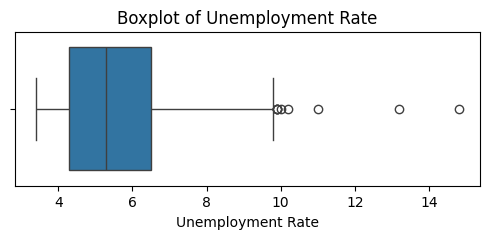

In [9]:
plt.figure(figsize=(6, 2))
sns.boxplot(x=df['Unemployment Rate'])
plt.title("Boxplot of Unemployment Rate")
plt.show()

SEASONAL DECOMPOSITION

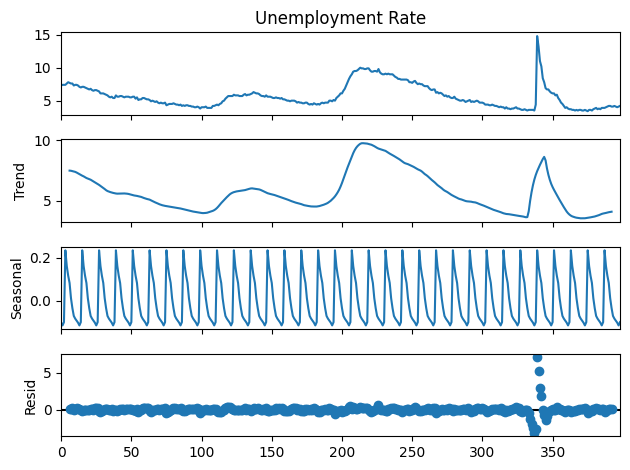

In [10]:
result = seasonal_decompose(df['Unemployment Rate'], model='additive', period=12)
result.plot()
plt.show()

AUTOCORRELATION ANALYSIS

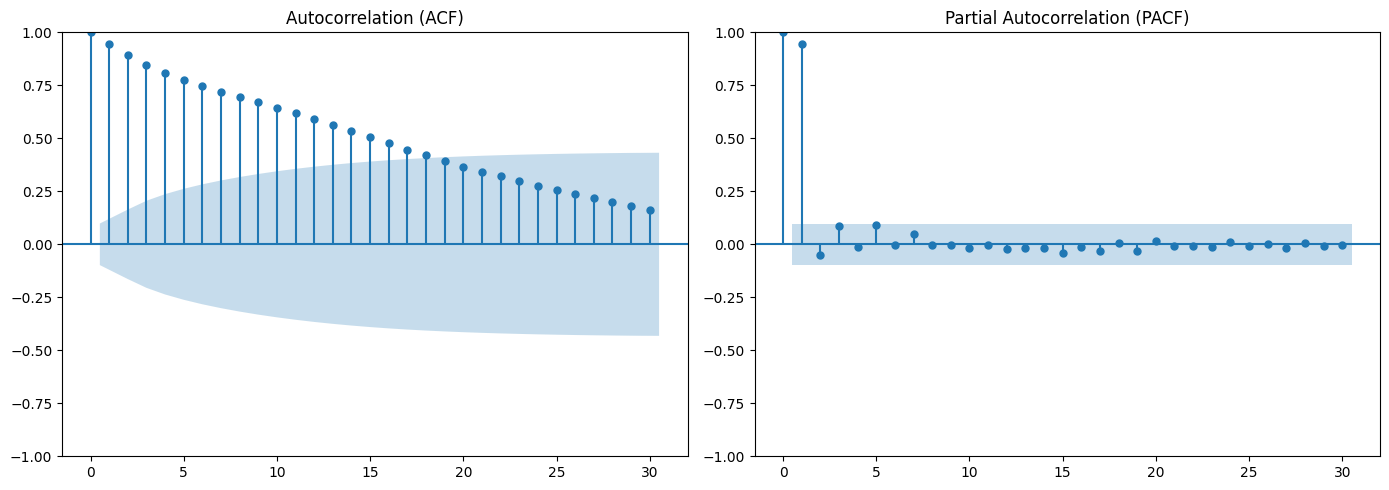

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
plot_acf(df['Unemployment Rate'], lags=30, ax=axes[0])
plot_pacf(df['Unemployment Rate'], lags=30, ax=axes[1])
axes[0].set_title('Autocorrelation (ACF)')
axes[1].set_title('Partial Autocorrelation (PACF)')
plt.tight_layout()
plt.show()

CORRELATION MATRIX

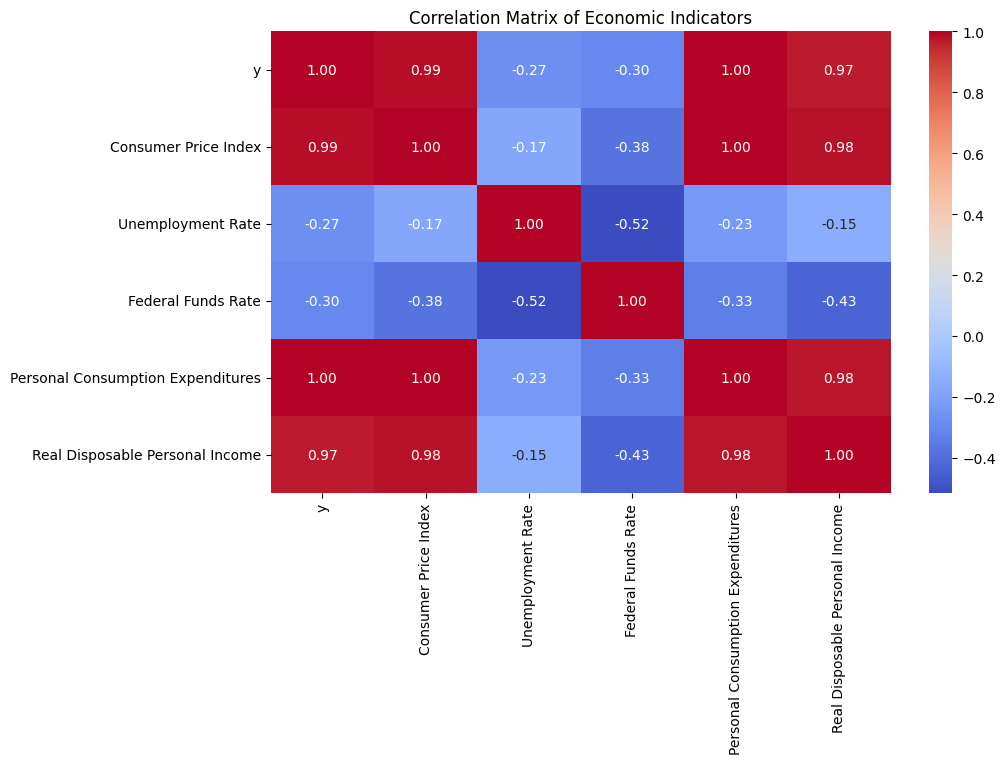

In [12]:
plt.figure(figsize=(10, 6))
sns.heatmap(df.drop(columns=['ds']).corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Correlation Matrix of Economic Indicators")
plt.show()

ROLLING MEAN (SMOOTH TREND)

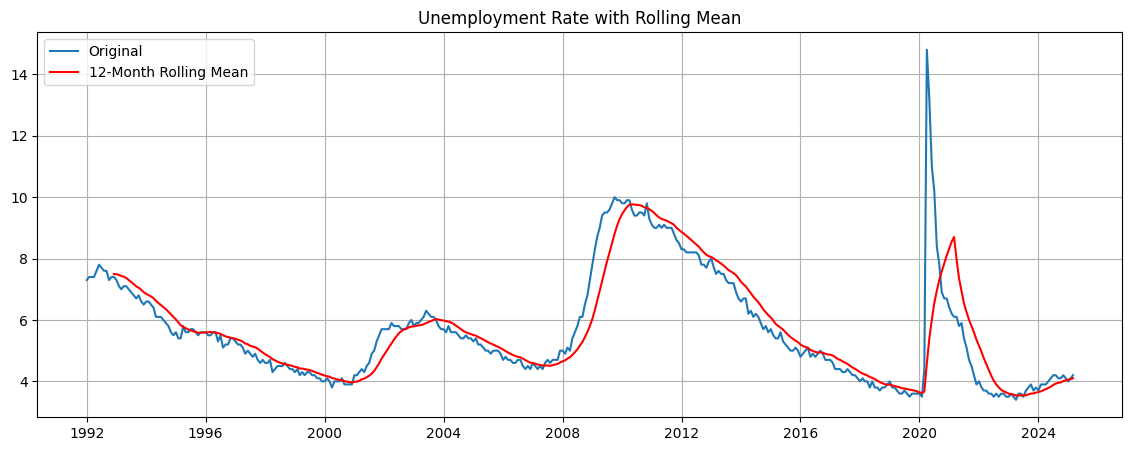

In [13]:
df['rolling_mean'] = df['Unemployment Rate'].rolling(window=12).mean()
plt.figure(figsize=(14, 5))
plt.plot(df['ds'], df['Unemployment Rate'], label='Original')
plt.plot(df['ds'], df['rolling_mean'], label='12-Month Rolling Mean', color='red')
plt.title("Unemployment Rate with Rolling Mean")
plt.legend()
plt.grid(True)
plt.show()

FIRST DIFFERENCE (STATIONARITY CHECK)

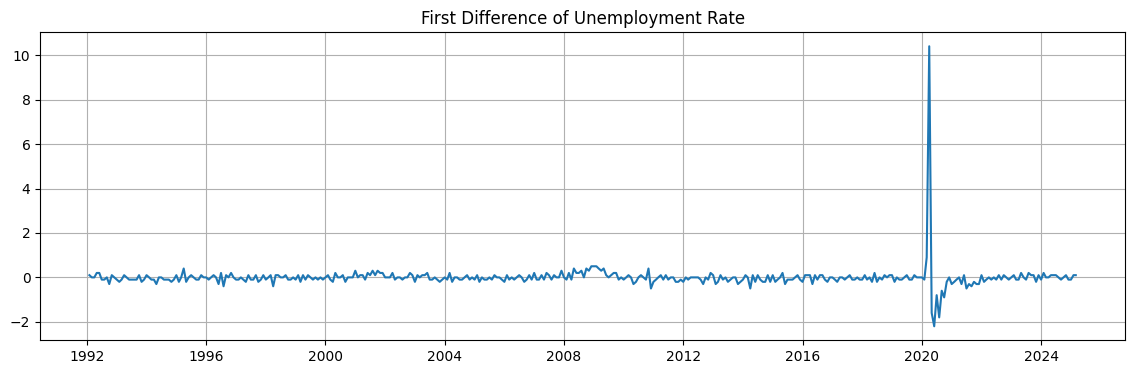

In [14]:
df['unrate_diff'] = df['Unemployment Rate'].diff()
plt.figure(figsize=(14, 4))
plt.plot(df['ds'], df['unrate_diff'], label='Change in Unemployment Rate')
plt.title("First Difference of Unemployment Rate")
plt.grid(True)
plt.show()

SEASONALITY HEATMAP

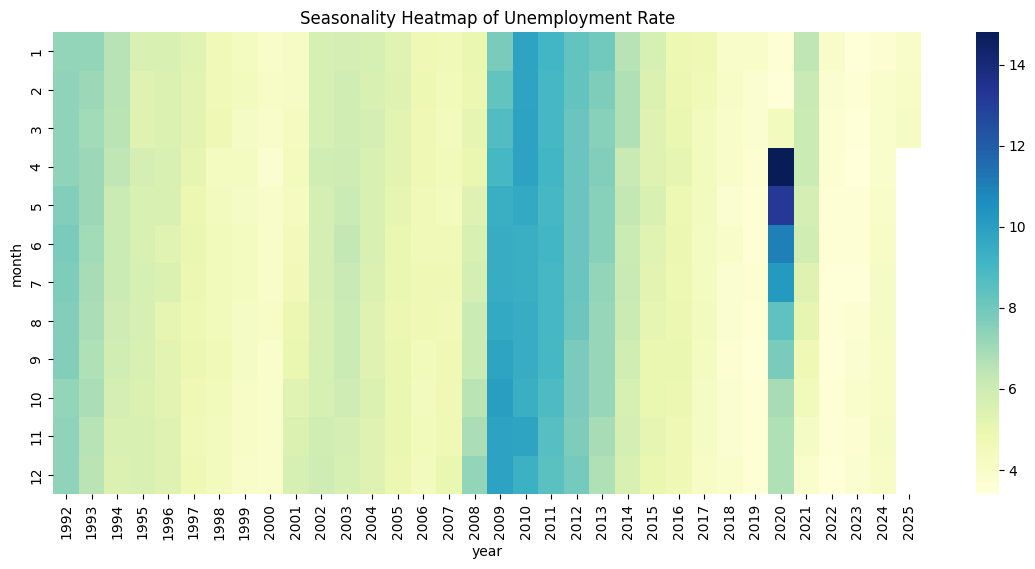

In [15]:
df['year'] = df['ds'].dt.year
df['month'] = df['ds'].dt.month
pivot = df.pivot_table(index='month', columns='year', values='Unemployment Rate')
plt.figure(figsize=(14, 6))
sns.heatmap(pivot, cmap='YlGnBu', annot=False)
plt.title("Seasonality Heatmap of Unemployment Rate")
plt.show()

# Preprocessing

In [16]:
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.model_selection import train_test_split

avoiding mutation

In [17]:
df_prep = df.copy()

Set datetime index

In [18]:
df_prep['ds'] = pd.to_datetime(df_prep['ds'])
df_prep.set_index('ds', inplace=True)

Check & fill missing values

In [19]:
df_prep = df_prep.asfreq('MS')
df_prep.interpolate(method='linear', inplace=True)

Feature engineering: Lag and diff (to stationarize)

In [20]:
df_diff = df_prep.diff().dropna()

Scale data

In [21]:
scaler = StandardScaler()
scaled_values = scaler.fit_transform(df_diff)
df_scaled = pd.DataFrame(scaled_values, index=df_diff.index, columns=df_diff.columns)

Create supervised learning format (for ML/LSTM)

In [22]:
def create_supervised(df, n_lags=12):
    df_supervised = pd.DataFrame()
    for i in range(n_lags, 0, -1):
        df_lagged = df.shift(i)
        df_lagged.columns = [f'{col}_lag{i}' for col in df.columns]
        df_supervised = pd.concat([df_supervised, df_lagged], axis=1)
    df_supervised = pd.concat([df_supervised, df], axis=1)
    df_supervised.dropna(inplace=True)
    return df_supervised

df_supervised = create_supervised(df_scaled, n_lags=12)

Train-test split (chronological) to prevent leakage

In [23]:
split_ratio = 0.8
split_index = int(len(df_supervised) * split_ratio)

train = df_supervised.iloc[:split_index]
test = df_supervised.iloc[split_index:]

X_train = train.drop(columns=['y'])
y_train = train['y']
X_test = test.drop(columns=['y'])
y_test = test['y']

# Deep Learning-Based Forecasting Models

In [24]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Input
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
import seaborn as sns

In [64]:
df_diff = df.drop(columns=['ds']).diff().dropna()

df_diff['Unemployment Rate'] = df_diff['Unemployment Rate'].clip(lower=-2, upper=2)

scaler = StandardScaler()
scaled_values = scaler.fit_transform(df_diff)
df_scaled = pd.DataFrame(scaled_values, index=df_diff.index, columns=df_diff.columns)

target_series = df_scaled['Unemployment Rate'].values

def create_sequences(data, seq_length):
    X, y = [], []
    for i in range(len(data) - seq_length):
        X.append(data[i:i + seq_length])
        y.append(data[i + seq_length])
    return np.array(X), np.array(y)

seq_length = 48
X, y = create_sequences(target_series, seq_length)
X = X.reshape((X.shape[0], X.shape[1], 1))

train_size = int(len(X) * 0.85)
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

def build_lstm_model(input_shape):
    model = Sequential([
        Input(shape=input_shape),
        LSTM(64, return_sequences=True),
        Dropout(0.2),
        LSTM(64, return_sequences=False),
        Dropout(0.2),
        Dense(32, activation='relu'),
        Dense(1)
    ])
    model.compile(optimizer='adam', loss='mse')
    return model

model = build_lstm_model((seq_length, 1))

early_stop = EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)
lr_reduce = ReduceLROnPlateau(monitor='val_loss', factor=0.3, patience=5, verbose=1)

history = model.fit(
    X_train, y_train,
    validation_split=0.1,
    epochs=200,
    batch_size=32,
    callbacks=[early_stop, lr_reduce],
    verbose=1
)

preds = model.predict(X_test).flatten()

def plot_predictions(y_true, y_pred, title='LSTM Forecast vs Actual (scaled)'):
    plt.figure(figsize=(14, 5))
    plt.plot(y_true, label='Actual', linewidth=2)
    plt.plot(y_pred, label='Predicted', linestyle='--')
    plt.title(title)
    plt.xlabel('Time Step')
    plt.ylabel('Scaled Value')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()


Epoch 1/200
9/9 ━━━━━━━━━━━━━━━━━━━━ 6s 124ms/step - loss: 0.4121 - val_loss: 8.8311 - learning_rate: 0.0010
Epoch 2/200
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 55ms/step - loss: 0.3840 - val_loss: 8.9625 - learning_rate: 0.0010
Epoch 3/200
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 55ms/step - loss: 0.3192 - val_loss: 9.0325 - learning_rate: 0.0010
Epoch 4/200
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 52ms/step - loss: 0.3066 - val_loss: 9.0742 - learning_rate: 0.0010
Epoch 5/200
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - loss: 0.2600 - val_loss: 9.3151 - learning_rate: 0.0010
Epoch 6/200
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - loss: 0.3242
Epoch 6: ReduceLROnPlateau reducing learning rate to 0.0003000000142492354.
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 56ms/step - loss: 0.3231 - val_loss: 9.2992 - learning_rate: 0.0010
Epoch 7/200
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - loss: 0.3203 - val_loss: 9.3001 - learning_rate: 3.0000e-04
Epoch 8/200
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - loss: 0.2969 - val_loss: 9.3321 - learning_rate: 3.0000e-0

# Evaluation

In [65]:
mse = mean_squared_error(y_test, preds)
mae = mean_absolute_error(y_test, preds)
r2 = r2_score(y_test, preds)

print(f'MSE: {mse:.4f}')
print(f'MAE: {mae:.4f}')
print(f'R2 Score: {r2:.4f}')

MSE: 0.3152
MAE: 0.4565
R2 Score: 0.1882


#plot

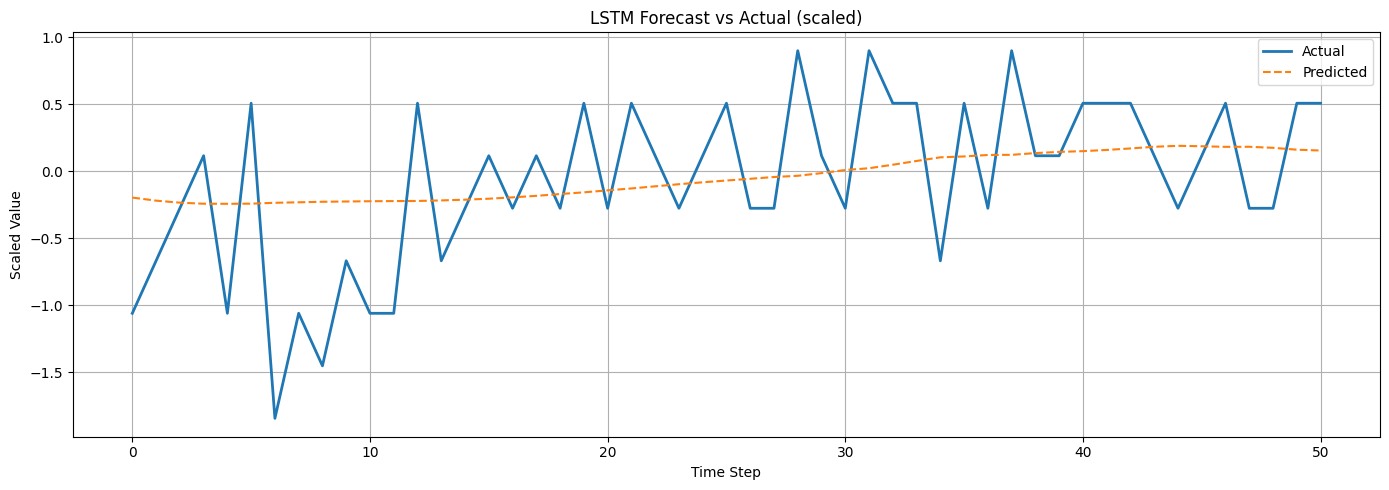

In [66]:
plot_predictions(y_test, preds)

# multi-variate LSTM

In [77]:
df_features = df.drop(columns=['ds'])
df_diff = df_features.diff().dropna()
df_diff['Unemployment Rate'] = df_diff['Unemployment Rate'].clip(lower=-2, upper=2)

selected_features = ['Personal Consumption Expenditures', 'unrate_diff',
                     'Real Disposable Personal Income', 'Federal Funds Rate',
                     'Unemployment Rate']
df_selected = df_diff[selected_features]

scaler = StandardScaler()
scaled = scaler.fit_transform(df_selected)
df_scaled = pd.DataFrame(scaled, columns=selected_features, index=df_diff.index)

def create_multivariate_sequences(data, target_column, seq_length):
    X, y = [], []
    target_index = data.columns.get_loc(target_column)
    for i in range(len(data) - seq_length):
        X.append(data.iloc[i:i+seq_length].values)
        y.append(data.iloc[i+seq_length, target_index])
    return np.array(X), np.array(y)

seq_length = 48
X, y = create_multivariate_sequences(df_scaled, 'Unemployment Rate', seq_length)

train_size = int(len(X) * 0.85)
X_train_mv, X_test_mv = X[:train_size], X[train_size:]
y_train_mv, y_test_mv = y[:train_size], y[train_size:]

def build_multivariate_lstm_model(input_shape):
    model = Sequential([
        Input(shape=input_shape),
        LSTM(64, return_sequences=True),
        Dropout(0.2),
        LSTM(64),
        Dropout(0.2),
        Dense(32, activation='relu'),
        Dense(1)
    ])
    model.compile(optimizer='adam', loss='mse')
    return model

model_mv = build_multivariate_lstm_model((seq_length, len(selected_features)))

early_stop = EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)
lr_reduce = ReduceLROnPlateau(monitor='val_loss', factor=0.3, patience=5, verbose=1)


history_mv = model_mv.fit(
    X_train_mv, y_train_mv,
    validation_split=0.1,
    epochs=200,
    batch_size=32,
    callbacks=[early_stop, lr_reduce],
    verbose=1
)

preds_mv = model_mv.predict(X_test).flatten()

def plot_predictions(y_true, y_pred, title='Multivariate LSTM Forecast vs Actual (scaled)'):
    plt.figure(figsize=(14, 5))
    plt.plot(y_true, label='Actual', linewidth=2)
    plt.plot(y_pred, label='Predicted', linestyle='--')
    plt.title(title)
    plt.xlabel('Time Step')
    plt.ylabel('Scaled Unemployment Rate')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()



Epoch 1/200
9/9 ━━━━━━━━━━━━━━━━━━━━ 5s 124ms/step - loss: 0.3567 - val_loss: 8.8297 - learning_rate: 0.0010
Epoch 2/200
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 86ms/step - loss: 0.3318 - val_loss: 8.9322 - learning_rate: 0.0010
Epoch 3/200
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 91ms/step - loss: 0.2835 - val_loss: 8.9497 - learning_rate: 0.0010
Epoch 4/200
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 50ms/step - loss: 0.3428 - val_loss: 9.1071 - learning_rate: 0.0010
Epoch 5/200
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 53ms/step - loss: 0.2955 - val_loss: 9.1796 - learning_rate: 0.0010
Epoch 6/200
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - loss: 0.3026
Epoch 6: ReduceLROnPlateau reducing learning rate to 0.0003000000142492354.
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 50ms/step - loss: 0.3011 - val_loss: 9.1511 - learning_rate: 0.0010
Epoch 7/200
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 52ms/step - loss: 0.3009 - val_loss: 9.1739 - learning_rate: 3.0000e-04
Epoch 8/200
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 54ms/step - loss: 0.2708 - val_loss: 9.2182 - learning_rate: 3.0000e-0

Multivariate LSTM Evaluation

In [78]:
mse = mean_squared_error(y_mv_test, preds_mv)
mae = mean_absolute_error(y_mv_test, preds_mv)
r2 = r2_score(y_mv_test, preds_mv)

print(f"[Multivariate LSTM] MSE: {mse:.4f}")
print(f"[Multivariate LSTM] MAE: {mae:.4f}")
print(f"[Multivariate LSTM] R2 Score: {r2:.4f}")

[Multivariate LSTM] MSE: 0.3562
[Multivariate LSTM] MAE: 0.4830
[Multivariate LSTM] R2 Score: 0.0825


Multivariate LSTM plotting

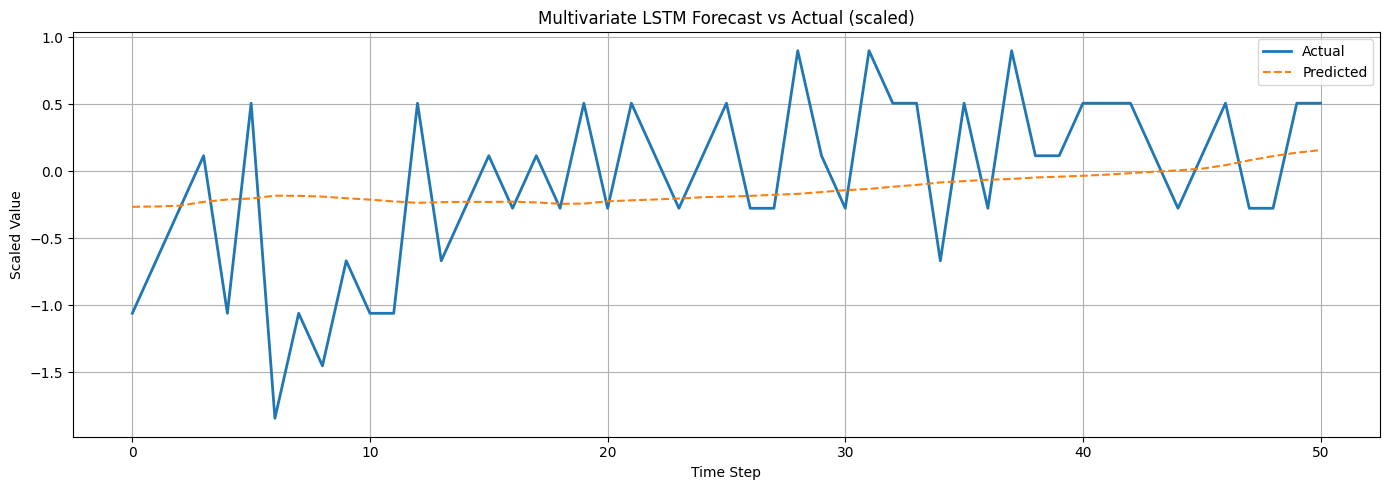

In [79]:
plot_predictions_mv(y_mv_test, preds_mv)

Comparison


Model Performance Comparison:

               Model       MSE       MAE  R2 Score
0    Univariate LSTM  0.356195  0.483011  0.082515
1  Multivariate LSTM  0.287318  0.436712  0.259927


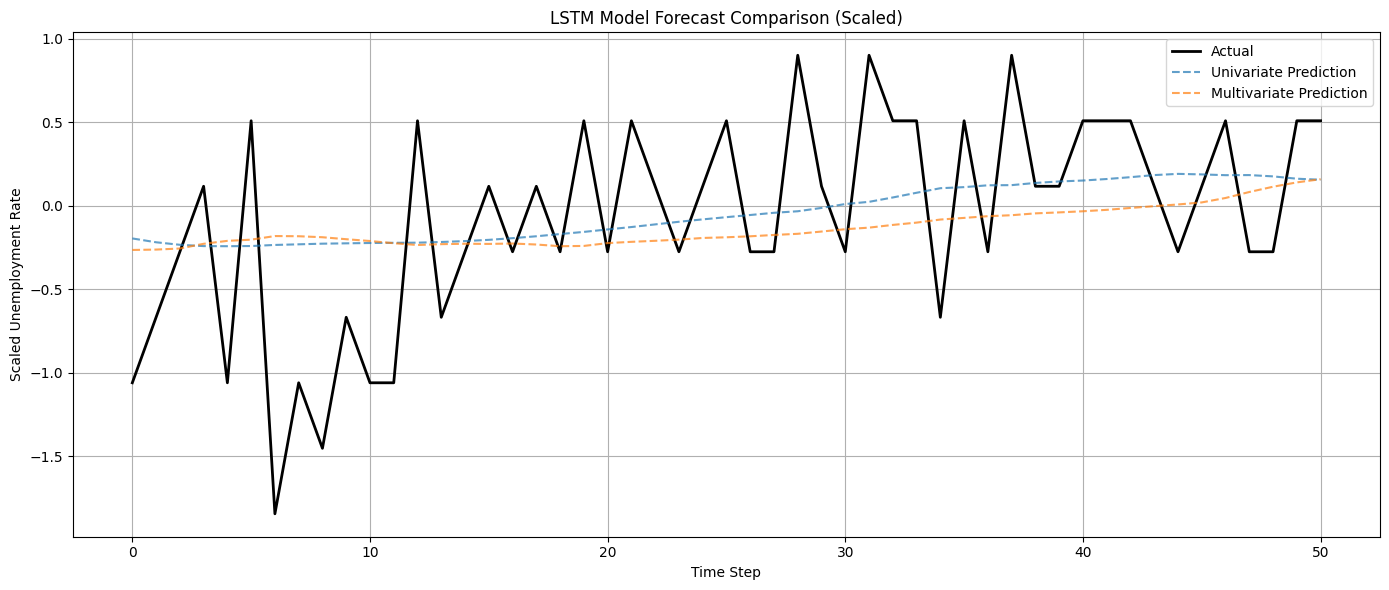

In [80]:
comparison_df = pd.DataFrame({
    'Model': ['Univariate LSTM', 'Multivariate LSTM'],
    'MSE': [mse, mse_mv],
    'MAE': [mae, mae_mv],
    'R2 Score': [r2, r2_mv]
})

print("\nModel Performance Comparison:\n")
print(comparison_df)

plt.figure(figsize=(14, 6))
plt.plot(y_test, label='Actual', color='black', linewidth=2)
plt.plot(preds, label='Univariate Prediction', linestyle='--', alpha=0.7)
plt.plot(preds_mv, label='Multivariate Prediction', linestyle='--', alpha=0.7)
plt.title("LSTM Model Forecast Comparison (Scaled)")
plt.xlabel("Time Step")
plt.ylabel("Scaled Unemployment Rate")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


# Interpretability and explainability

In [70]:
!pip install shap lime scikit-learn


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 4.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for lime: filename=lime-0.2.0.1-py3-none-any.whl size=283834 sha256=ad1f1b38e6d28d2ec179470d39ab29ab6a5c79dc4c49a7b008ab839e5e74be2e
  Stored in directory: /root/.cache/pip/wheels/85/fa/a3/9c2d44c9f3cd77cf4e533b58900b2bf4487f2a17e8ec212a3d
Successfully built lime


In [74]:
import shap
import lime
import lime.lime_tabular
import matplotlib.pyplot as plt
from sklearn.inspection import PartialDependenceDisplay
from sklearn.inspection import partial_dependence
from sklearn.preprocessing import FunctionTransformer
import pandas as pd
import numpy as np

residual analysis for the univariate LSTM model

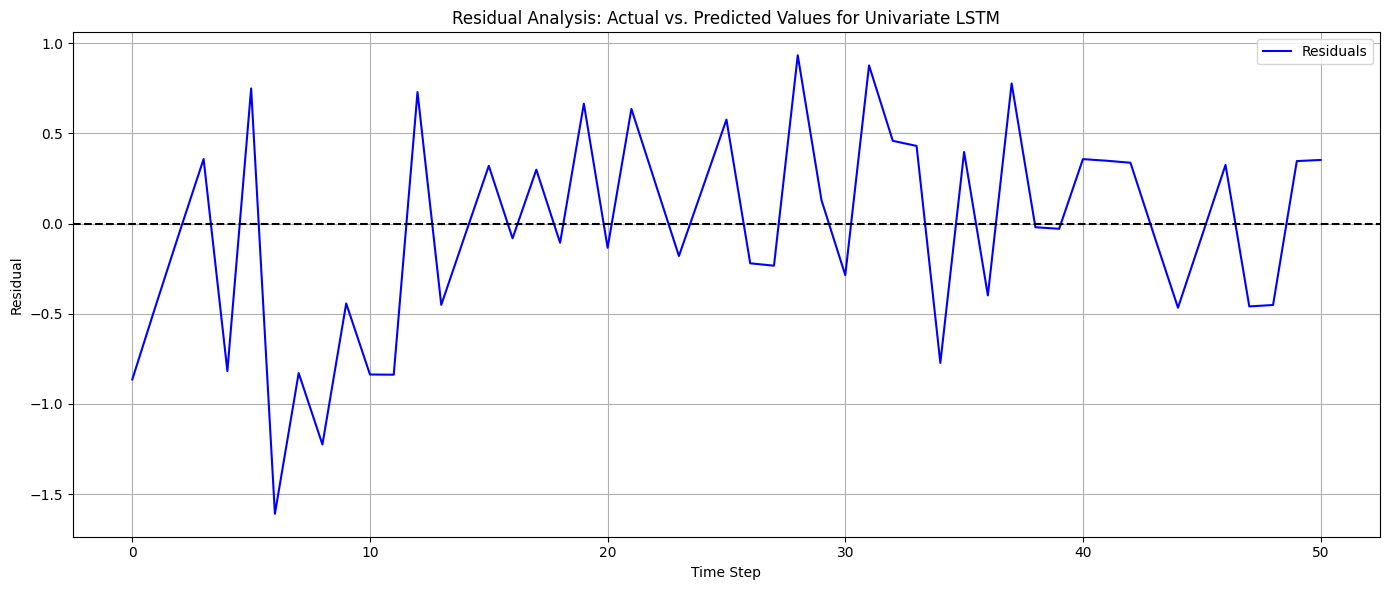

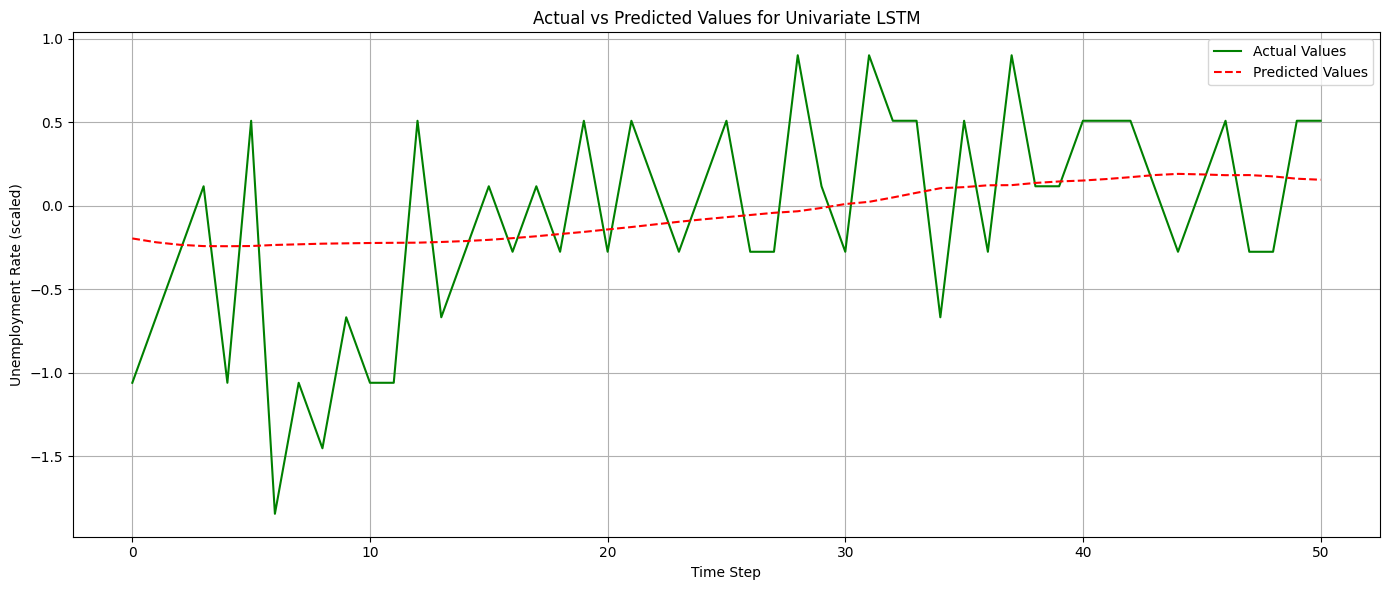

In [115]:
residuals = y_test - preds

plt.figure(figsize=(14, 6))
plt.plot(residuals, label='Residuals', color='blue')
plt.axhline(y=0, color='black', linestyle='--')
plt.title('Residual Analysis: Actual vs. Predicted Values for Univariate LSTM')
plt.xlabel('Time Step')
plt.ylabel('Residual')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

plt.figure(figsize=(14, 6))
plt.plot(y_test, label='Actual Values', color='green')
plt.plot(preds, label='Predicted Values', linestyle='--', color='red')
plt.title('Actual vs Predicted Values for Univariate LSTM')
plt.xlabel('Time Step')
plt.ylabel('Unemployment Rate (scaled)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

shape on Multivariate LSTM Model

In [105]:
n_time_steps = seq_length
n_features = len(selected_features)

def predict_fn_reshaped(X_flat):
    X_reshaped = X_flat.reshape((-1, n_time_steps, n_features))
    return model_mv.predict(X_reshaped).flatten()


4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step


  0%|          | 0/5 [00:00<?, ?it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 164ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step


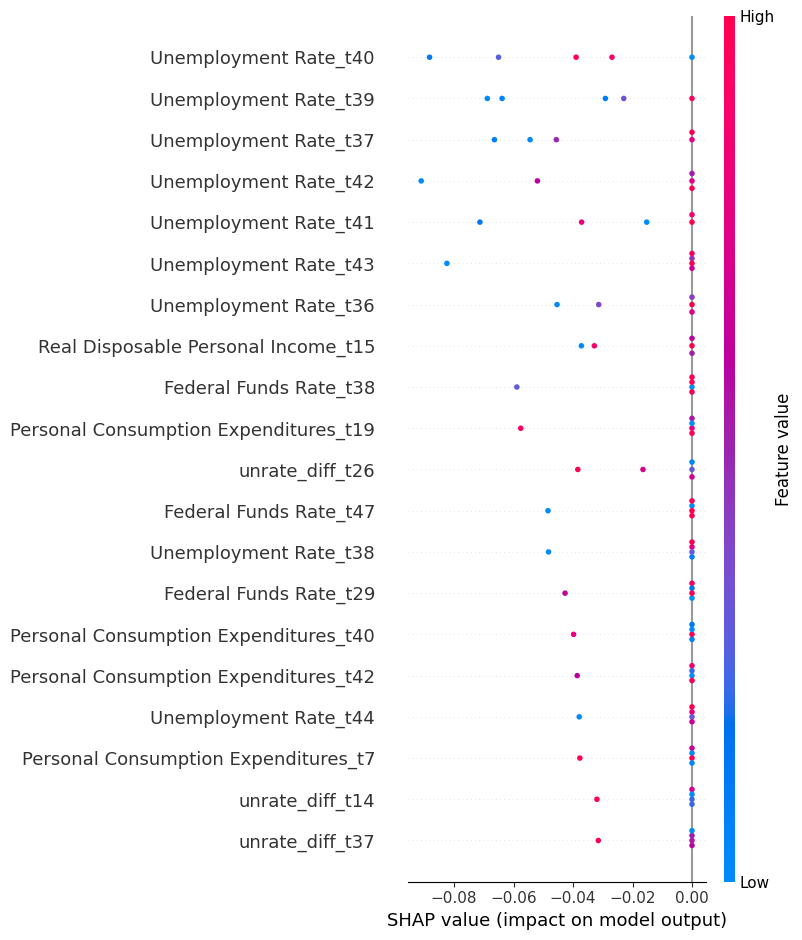

In [106]:
X_test_flat = X_test_mv[:5].reshape((5, -1))
background_flat = X_train_mv[:100].reshape((100, -1))

explainer = shap.KernelExplainer(predict_fn_reshaped, background_flat)
shap_values = explainer.shap_values(X_test_flat, nsamples=100)

flat_feature_names = [f"{feat}_t{t}" for t in range(seq_length) for feat in selected_features]

shap.summary_plot(shap_values, X_test_flat, feature_names=flat_feature_names)


Permutation Feature Importance for  Multivariate LSTM Model

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step


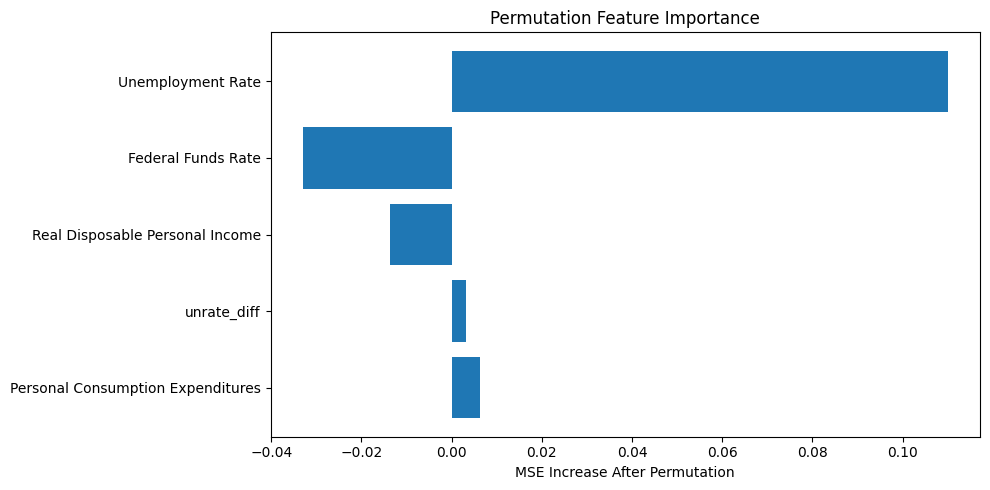

In [108]:
baseline_preds = model_mv.predict(X_test_mv).flatten()
baseline_mse = mean_squared_error(y_test_mv, baseline_preds)

feature_importance = []

for i in range(X_test_mv.shape[2]):
    X_test_copy = X_test_mv.copy()
    np.random.shuffle(X_test_copy[:, :, i])
    permuted_preds = model_mv.predict(X_test_copy).flatten()
    permuted_mse = mean_squared_error(y_test_mv, permuted_preds)
    importance = permuted_mse - baseline_mse
    feature_importance.append(importance)

plt.figure(figsize=(10, 5))
plt.barh(selected_features, feature_importance)
plt.xlabel("MSE Increase After Permutation")
plt.title("Permutation Feature Importance")
plt.tight_layout()
plt.show()


Occlusion Sensitivity for Multivariate LSTM Model

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step 
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
2/2 ━━━━━━━

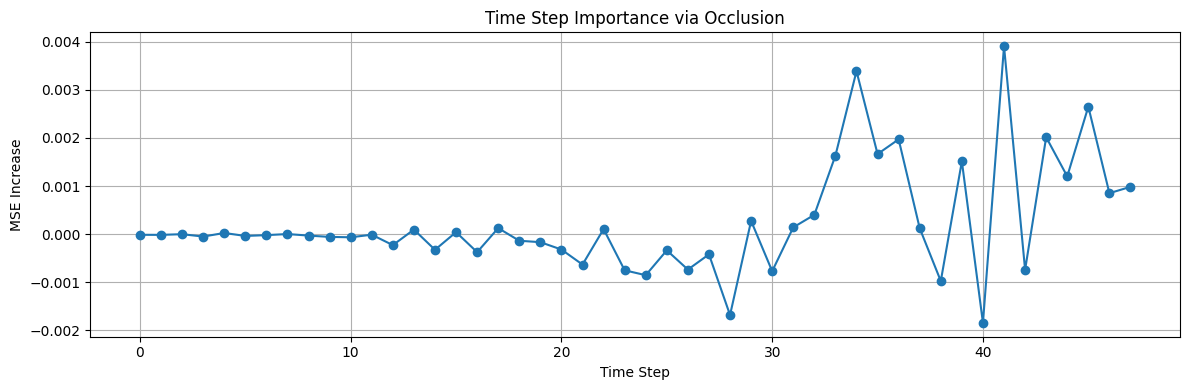

In [109]:
time_importance = []

for t in range(seq_length):
    X_test_occluded = X_test_mv.copy()
    X_test_occluded[:, t, :] = 0
    occluded_preds = model_mv.predict(X_test_occluded).flatten()
    mse = mean_squared_error(y_test_mv, occluded_preds)
    time_importance.append(mse - baseline_mse)

plt.figure(figsize=(12, 4))
plt.plot(range(seq_length), time_importance, marker='o')
plt.title("Time Step Importance via Occlusion")
plt.xlabel("Time Step")
plt.ylabel("MSE Increase")
plt.grid(True)
plt.tight_layout()
plt.show()


Individual Conditional Expectation (ICE) Plot

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 109ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 114ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 173ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step


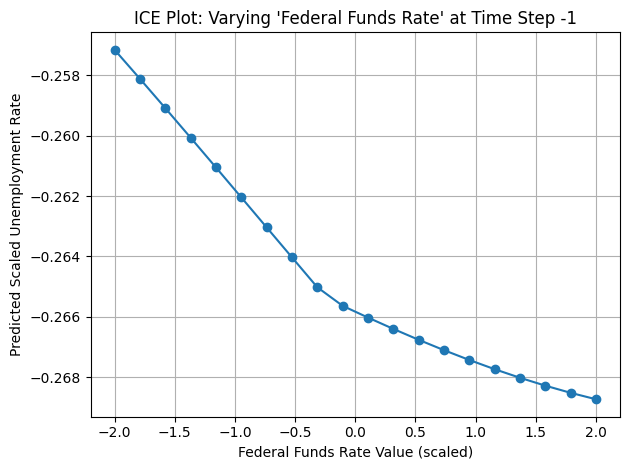

In [111]:
def plot_ice(model, X_sample, feature_index, feature_name, timestep=-1, num_points=20):

    X_orig = X_sample.copy()
    feature_values = np.linspace(-2, 2, num_points)
    preds = []

    for val in feature_values:
        X_temp = X_orig.copy()
        X_temp[timestep, feature_index] = val
        pred = model.predict(X_temp[np.newaxis, :, :])[0][0]
        preds.append(pred)

    plt.plot(feature_values, preds, marker='o')
    plt.xlabel(f"{feature_name} Value (scaled)")
    plt.ylabel("Predicted Scaled Unemployment Rate")
    plt.title(f"ICE Plot: Varying '{feature_name}' at Time Step {timestep}")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

sample_input = X_test_mv[0]
feature_idx = selected_features.index('Federal Funds Rate')
plot_ice(model_mv, sample_input, feature_idx, 'Federal Funds Rate', timestep=-1)


Individual Conditional Expectation (ICE) Plot

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 110ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step


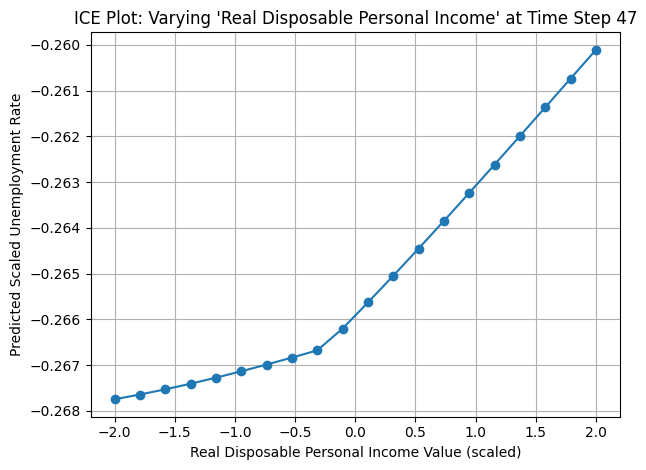

In [112]:
def plot_ice(model, X_sample, feature_index, feature_name, timestep=-1, num_points=20):

    X_orig = X_sample.copy()
    feature_values = np.linspace(-2, 2, num_points)
    preds = []

    for val in feature_values:
        X_temp = X_orig.copy()
        X_temp[timestep, feature_index] = val
        pred = model.predict(X_temp[np.newaxis, :, :])[0][0]
        preds.append(pred)

    plt.plot(feature_values, preds, marker='o')
    plt.xlabel(f"{feature_name} Value (scaled)")
    plt.ylabel("Predicted Scaled Unemployment Rate")
    plt.title(f"ICE Plot: Varying '{feature_name}' at Time Step {timestep}")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

sample_input = X_test_mv[0]
feature_idx = selected_features.index('Real Disposable Personal Income')
plot_ice(model_mv, sample_input, feature_idx, 'Real Disposable Personal Income', timestep=47)
